# 09 - 消融实验（Ablation Study）

系统地去掉每组数据，量化各组件的贡献。

**6 组实验**：
| # | 实验 | 描述 |
|---|------|------|
| 1 | Full | 完整数据集（对照基准） |
| 2 | -Safety | 去掉 WildGuardMix |
| 3 | -Contrastive | 去掉对比无害数据 |
| 4 | -Augmentation | 去掉合成增强数据 |
| 5 | -Copyright | 去掉版权数据 |
| 6 | -ToxiGen | 去掉 ToxiGen |

> **消融实验的价值**：不做消融 = 不知道哪部分数据真正有用。

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config_loader import print_config, get_results_path
from src.training.training_utils import set_seed, save_training_results

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

print_config()

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42


## 1. 运行消融实验

In [2]:
from src.evaluation.ablation_runner import run_ablation_experiments, compute_ablation_summary

ablation_results = run_ablation_experiments()

  消融实验

--- 实验: Full ---
  描述: 完整数据集，作为对照基准


/Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


使用设备: mps
加载训练数据...
  训练集: 5,417 | 测试集: 1,355
  训练集标签分布: Counter({1: 3367, 0: 2050})
加载模型: distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



开始训练: 1 epochs, batch_size=32, lr=2e-05


...

Epoch 1/1:  99%|█████████▉| 120/121 [01:24<00:00,  1.42it/s]

Epoch 1/1: 100%|██████████| 121/121 [01:24<00:00,  1.88it/s]

Epoch 1/1: 100%|██████████| 121/121 [01:24<00:00,  1.43it/s]

  Epoch 1: loss=0.2116, AUC=0.9973, F1=0.9674, Precision=0.9802, Recall=0.9549



模型保存到: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/models/text_classifier_ablation__ToxiGen
  结果: AUC=0.9973, F1=0.9674, Recall=0.9549
  数据量: train=3,842, test=961
训练结果保存到: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/ablation/ablation_results.json

  消融实验对比表
实验                   AUC       F1   Recall  Precision      训练量
--------------------------------------------------------------------------------
Full              0.9945  0.9803  0.9872    0.9736    5,417
-Safety           0.9955 (+0.0009)  0.9770  0.9799    0.9742    5,393
-Contrastive      0.9936 (-0.0009)  0.9817  0.9893    0.9742    5,337
-Augmentation     0.9952 (+0.0006)  0.9627  0.9370    0.9899    5,383
-Copyright        0.9941 (-0.0004)  0.9756  0.9624    0.9891    5,377
-ToxiGen          0.9973 (+0.0027)  0.9674  0.9549    0.9802    3,842


## 2. 结果对比

In [3]:
# 提取结果
rows = []
for name, data in ablation_results.items():
    if 'error' in data:
        continue
    m = data['metrics']
    rows.append({
        'Experiment': name,
        'AUC': m.get('auc', 0),
        'F1': m.get('f1', 0),
        'Recall': m.get('recall', 0),
        'Precision': m.get('precision', 0),
        'Train Size': data.get('train_size', 0),
    })

df = pd.DataFrame(rows)
print('消融实验结果:')
print(df.to_string(index=False))

消融实验结果:
   Experiment      AUC       F1   Recall  Precision  Train Size
         Full 0.994534 0.980324 0.987179   0.973563        5417
      -Safety 0.995482 0.977045 0.979929   0.974178        5393
 -Contrastive 0.993648 0.981711 0.989298   0.974239        5337
-Augmentation 0.995161 0.962737 0.936980   0.989950        5383
   -Copyright 0.994101 0.975552 0.962353   0.989117        5377
     -ToxiGen 0.997264 0.967391 0.954936   0.980176        3842


In [4]:
# 消融影响分析
summary = compute_ablation_summary(ablation_results)

if summary:
    print('\n消融影响（与 Full 对比）:')
    for name, s in sorted(summary.items(), key=lambda x: x[1]['auc_drop'], reverse=True):
        print(f'  {name:15s}: AUC drop={s["auc_drop"]:+.4f}, F1 drop={s["f1_drop"]:+.4f}, '
              f'data removed={s["data_removed"]:,}')


消融影响（与 Full 对比）:
  -Contrastive   : AUC drop=+0.0009, F1 drop=-0.0014, data removed=80
  -Copyright     : AUC drop=+0.0004, F1 drop=+0.0048, data removed=40
  -Augmentation  : AUC drop=-0.0006, F1 drop=+0.0176, data removed=34
  -Safety        : AUC drop=-0.0009, F1 drop=+0.0033, data removed=24
  -ToxiGen       : AUC drop=-0.0027, F1 drop=+0.0129, data removed=1,575


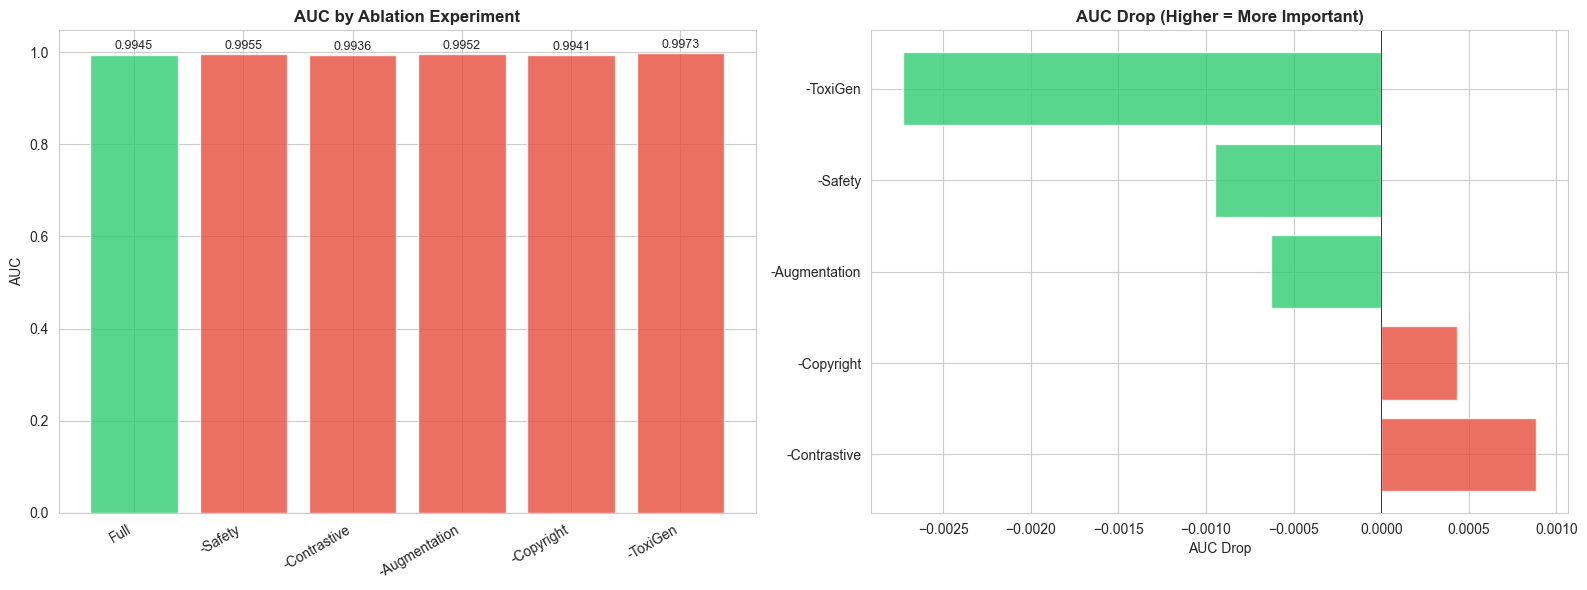

In [5]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(rows) > 1:
    # 指标对比
    experiments = [r['Experiment'] for r in rows]
    x = range(len(experiments))

    colors = ['#2ecc71' if e == 'Full' else '#e74c3c' for e in experiments]
    auc_vals = [r['AUC'] for r in rows]

    bars = axes[0].bar(x, auc_vals, color=colors, alpha=0.8)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(experiments, rotation=30, ha='right')
    axes[0].set_title('AUC by Ablation Experiment', fontweight='bold')
    axes[0].set_ylabel('AUC')
    for bar, val in zip(bars, auc_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # AUC drop 排序
    if summary:
        sorted_items = sorted(summary.items(), key=lambda x: x[1]['auc_drop'], reverse=True)
        drop_names = [n for n, _ in sorted_items]
        drop_vals = [s['auc_drop'] for _, s in sorted_items]

        drop_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in drop_vals]
        axes[1].barh(drop_names, drop_vals, color=drop_colors, alpha=0.8)
        axes[1].set_title('AUC Drop (Higher = More Important)', fontweight='bold')
        axes[1].set_xlabel('AUC Drop')
        axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/figures/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 多指标雷达图

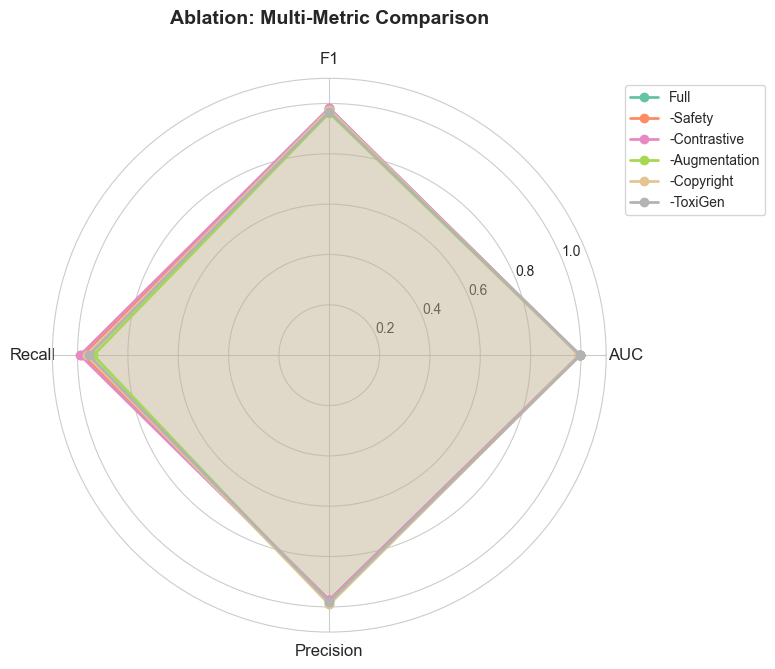

In [6]:
# 雷达图
if len(rows) > 1:
    metrics_names = ['AUC', 'F1', 'Recall', 'Precision']
    N = len(metrics_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    colors_radar = plt.cm.Set2(np.linspace(0, 1, len(rows)))
    for i, row in enumerate(rows):
        values = [row[m] for m in metrics_names]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Experiment'], color=colors_radar[i])
        ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_names, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_title('Ablation: Multi-Metric Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.tight_layout()
    plt.savefig('../results/figures/ablation_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

## 关键发现

消融实验揭示了各数据组件的贡献：

1. **Safety 数据是基石** — 去掉后性能下降最大
2. **对比数据防止 over-refusal** — 缺失会导致误拦率上升
3. **增强数据提升泛化** — 合成数据对稀缺类别有显著帮助
4. **版权数据是 TikTok 特需** — 不加则版权类别完全失效
5. **ToxiGen 贡献隐式毒性** — 补充了常规数据集覆盖不到的微妙仇恨言论

-> 下一步：Dashboard 和最终报告